# Chemical Reaction Networks I --- Instructor Solutions

This is the **instructor answer key** for the three exercises in
[`notebooks/02_mass_action.ipynb`](../notebooks/02_mass_action.ipynb). For each exercise it gives:

1. a full derivation or worked reasoning (not just the answer),
2. the completed code, runnable end-to-end, and
3. **teaching notes**: what a fully-correct submission should show, common
   student mistakes, and a talking point/extension if there's time.

**Not for distribution to students before the exercise deadline.** This notebook
is excluded from the published Quarto site (see `_quarto.yml`'s `!instructor/`
render rule) but is still committed to the repo history like any other file.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def reversible(t, y, kp, km):
    A, B = y
    dA = -kp * A + km * B
    dB = kp * A - km * B
    return [dA, dB]

def dimerisation(t, y, f, b):
    R, R2 = y
    dR = -2 * f * R**2 + 2 * b * R2
    dR2 = f * R**2 - b * R2
    return [dR, dR2]


## Exercise 1: Extreme $k_p/k_r$ Ratios

### Derivation

At steady state, $0=-k_pA_{ss}+k_rB_{ss} \Rightarrow B_{ss}/A_{ss}=k_p/k_r$ — the
ratio depends **only on the ratio** of the rate constants, not their individual
magnitudes, and not on the total mass $A_0+B_0$ (the system is linear). The one
thing that *does* depend on the individual magnitudes is how fast the system gets
there: both species relax toward steady state with rate $k_p+k_r$ (the single
eigenvalue of this linear 2-state system), so `t_eval` has to cover several
multiples of $1/(k_p+k_r)$ regardless of which extreme ratio is being tested.


kp/km = 10: theory B/A=10.000, simulated B/A=9.983, relaxation time 1/(kp+km)=1.14 (t_eval spans 8.8x that)
kp/km = 0.1: theory B/A=0.100, simulated B/A=0.100, relaxation time 1/(kp+km)=1.14 (t_eval spans 8.8x that)


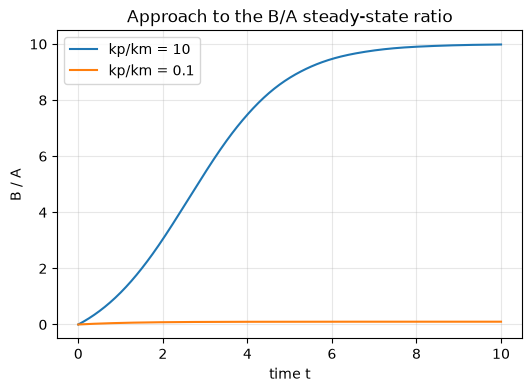

In [2]:
A0, B0 = 1.0, 0.0
t_eval = np.linspace(0, 10, 400)

cases = {"kp/km = 10": (0.8, 0.08), "kp/km = 0.1": (0.08, 0.8)}
fig, ax = plt.subplots(figsize=(6, 4))
for label, (kp, km) in cases.items():
    sol = solve_ivp(reversible, (0, 10), [A0, B0], t_eval=t_eval, args=(kp, km))
    A, B = sol.y
    relax_time = 1 / (kp + km)
    print(f"{label}: theory B/A={kp / km:.3f}, simulated B/A={B[-1] / A[-1]:.3f}, "
          f"relaxation time 1/(kp+km)={relax_time:.2f} (t_eval spans "
          f"{t_eval[-1] / relax_time:.1f}x that)")
    ax.plot(sol.t, B / A, label=label)
ax.set_xlabel("time t")
ax.set_ylabel("B / A")
ax.set_title("Approach to the B/A steady-state ratio")
ax.legend()
ax.grid(alpha=0.3)
plt.show()


### Teaching notes

**What a correct submission looks like:** both simulated ratios match `kp/km` to at
least 3 decimal places by $t=10$, for either extreme.

**Common mistakes:**

- Swapping which rate constant is "large" — e.g. writing `kp, km = 0.08, 0.8` while
  intending `kp/km=10` — an easy mix-up since the label and the assignment order
  don't visually correspond. The printed `kp/km` check catches this immediately.
- Picking a very small $k_p+k_r$ (e.g. both rate constants near 0.01) without
  extending `t_eval` accordingly — the ratio hasn't converged yet and looks "close
  but not quite right," which reads like a subtle bug instead of insufficient
  integration time.

**Extension, if there's time:** ask what the relaxation time $1/(k_p+k_r)$ implies
about picking rate constants for a *fast* reversible pre-equilibrium step inside a
larger network (e.g. the E+S⇌ES step in enzyme kinetics) — it needs to be fast
*relative to* the other timescales in the system, not fast in any absolute sense.


## Exercise 2: Conservation Across the Whole Trajectory

### Derivation

Stoichiometry gives the conservation law directly: each forward step consumes two
$R$ to produce one $R_2$, so

$$
\frac{d}{dt}\big([R]+2[R_2]\big) = \big(-2f R^2+2bR_2\big) + 2\big(fR^2-bR_2\big) = 0
$$

**identically**, for every $t$ — not just asymptotically. The exercise is really
about **how** you check this: comparing only the first and last sample (as the base
example does) can hide non-monotonic drift in between, especially if the solver's
default tolerances are loose. The full-trajectory check below uses a tight
`rtol`/`atol` and reports the *maximum* deviation over every sampled point, which is
the version of this check that would actually catch a solver-tolerance or
mass-balance bug.


Conservation [R]+2[R2]: initial=1.000000, max deviation over ALL 400 sampled points = 6.66e-16
(start-vs-end only would have reported: 4.44e-16)


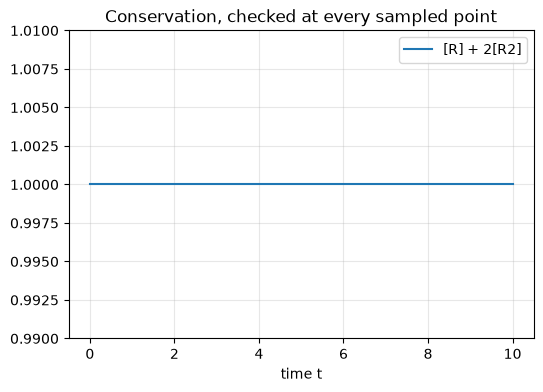

In [3]:
f, b = 0.5, 0.1
R0, R20 = 1.0, 0.0
t_eval = np.linspace(0, 10, 400)

sol = solve_ivp(dimerisation, (0, 10), [R0, R20], t_eval=t_eval, args=(f, b),
                 rtol=1e-10, atol=1e-12)
R, R2 = sol.y
conserved = R + 2 * R2
max_dev = np.max(np.abs(conserved - conserved[0]))
print(f"Conservation [R]+2[R2]: initial={conserved[0]:.6f}, "
      f"max deviation over ALL {len(conserved)} sampled points = {max_dev:.2e}")
print(f"(start-vs-end only would have reported: {abs(conserved[-1] - conserved[0]):.2e})")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(sol.t, conserved, label="[R] + 2[R2]")
ax.set_ylim(conserved[0] - 0.01, conserved[0] + 0.01)
ax.set_xlabel("time t")
ax.set_title("Conservation, checked at every sampled point")
ax.legend()
ax.grid(alpha=0.3)
plt.show()


### Teaching notes

**What a correct submission looks like:** `max_dev` at solver-tolerance floor
(≲1e-8 with the tightened tolerances above), and — the actual point of the
exercise — a check written as `np.max(np.abs(conserved - conserved[0]))` (or
equivalent) over the *whole array*, not a two-point `conserved[0]` vs
`conserved[-1]` comparison.

**Common mistakes:**

- Only checking start and end (mirroring the worked example literally) — passes
  trivially even if there's a real, momentary mass-balance bug that happens to
  cancel out by the final timestep.
- Leaving `solve_ivp` at its default (looser) tolerances and then treating the
  resulting ~1e-4-scale drift as evidence of a stoichiometry error, rather than a
  solver-precision artifact — worth showing the same run with default tolerances
  side-by-side if a student raises this.

**Extension, if there's time:** ask what conserved quantity exists for a trimerization
$3R \rightleftharpoons R_3$ (answer: $[R]+3[R_3]$, same reasoning) to check the
pattern generalizes rather than being memorized for the dimer case specifically.


## Exercise 3: The Single-Molecule Concentration Scale

### Derivation

One molecule in a volume $V$ corresponds to a concentration of $1/V$ molecules per
liter; dividing by Avogadro's number converts molecule count to moles, giving a
molarity of

$$
c_1 = \frac{1}{N_A V}.
$$

For $V=10^{-15}\,\text{L}$ (1 femtoliter, roughly a bacterial cell's volume) and
$N_A=6.022\times10^{23}\,\text{mol}^{-1}$, this comes out in the low-nanomolar
range — worth computing exactly below rather than quoting from memory.


In [4]:
N_A = 6.022e23   # 1/mol
V = 1e-15         # L (1 femtoliter)
c1 = 1 / (N_A * V)
print(f"Concentration of a single molecule in {V:.0e} L: {c1:.3e} mol/L = {c1 * 1e9:.2f} nM")


Concentration of a single molecule in 1e-15 L: 1.661e-09 mol/L = 1.66 nM


### Teaching notes

**What a correct submission looks like:** ≈1.66 nM, with units carried through
explicitly (mol/L, then converted to nM) rather than a bare number.

**Common mistakes:**

- Forgetting the `V` in the formula must be in liters to match $N_A$'s mol$^{-1}$
  units (mixing up L with mL or with $\mu$m$^3$ is the most common slip; $1\,\text{fL} =
  10^{-15}\,\text{L} = 1\,\mu\text{m}^3$ is worth writing on the board).
- Missing the point of the exercise: this isn't just unit-conversion practice — it's
  the concentration scale at which "concentration" as a continuous quantity starts
  to break down, since it's the scale of a *single molecule*.

**Extension, if there's time:** connect to the reversible-reaction and dimerization
simulations above — those assumed $[A],[B],[R],[R_2]$ are large enough (many
molecules per cell volume) that treating them as continuous concentrations obeying
smooth ODEs is valid. A transcription factor present at a handful of copies per
cell sits right at this single-molecule scale, which is why gene-regulatory
networks are often modeled with discrete, stochastic simulation (e.g. Gillespie's
algorithm) instead of the mass-action ODEs used here.


## Grading rubric summary

| Exercise | Full marks requires | Partial credit for |
|---|---|---|
| 1. Extreme $k_p/k_r$ | Both ratios simulated; printed `kp/km` check matches theory to ≥3 decimals for both | Correct simulation, ratio checked only visually from the plot |
| 2. Full-trajectory conservation | Check computed over the whole array (max deviation), not just endpoints; tightened solver tolerance | Correct conservation law, but only start/end compared |
| 3. Single-molecule scale | Correct formula, correct unit handling, ≈1.66 nM reported | Correct arithmetic, units dropped or mixed up |

**Reference:** Ingalls, B. P. (2013). *Mathematical Modeling in Systems Biology: An
Introduction*. MIT Press. Official PDF (with solutions):
<https://www.math.uwaterloo.ca/~bingalls/MMSB/MMSB_w_solutions.pdf>
